In [ ]:
from pathlib import Path

# Unpacked Zenodo archive. Expected subdirectories:
#   workflows/  normalized_workflows/  54_workflows_to_label/
# Change this path after downloading the dataset.
DATASET_DIR = Path("../zenodo_dataset")
WORKFLOWS_DIR = DATASET_DIR / "workflows"
NORMALIZED_DIR = DATASET_DIR / "normalized_workflows"
LABELED_WORKFLOWS_DIR = DATASET_DIR / "54_workflows_to_label"

SCANNERS_DIR = Path("../scanners")
SCANNERS_OUTPUT_DIR = Path("../scanners_output")
RULES_FILE = Path("../capabilities/rules_map.csv")

# Ground-truth labels used by the accuracy study.
MANUAL_FILE = Path("../results/ground-truth.csv")

# Generated accuracy artifacts (created by this notebook).
ACCURACY_DIR = Path("../accuracy")
TOOLS_LABEL_DIR = ACCURACY_DIR / "tools_label"
ACCURACY_RESULTS_DIR = ACCURACY_DIR / "results"
ACCURACY_DIR.mkdir(parents=True, exist_ok=True)
TOOLS_LABEL_DIR.mkdir(parents=True, exist_ok=True)
ACCURACY_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
import pandas as pd
import csv
import re
from pathlib import Path


# ============================================================
# Paths
# ============================================================


OUTPUT_FILE = ACCURACY_RESULTS_DIR / "manual_weakness_summary.csv"


# ============================================================
# All 10 weakness classes
# ============================================================

WEAKNESSES = [
    "AIW",
    "CFW",
    "EPW",
    "GRCW",
    "HGW",
    "IW",
    "KVCW",
    "PTW",
    "SEW",
    "UDW",
]


# ============================================================
# Normalize weakness names
# ============================================================

WEAKNESS_MAP = {
    "artifact-integrity-weakness": "AIW",
    "control-flow-weakness": "CFW",
    "excessive-permission-weakness": "EPW",
    "github-runner-compatibility-weakness": "GRCW",
    "hardening-gap-weakness": "HGW",
    "injection-weakness": "IW",
    "known-vulnerable-component-weakness": "KVCW",
    "privileged-trigger-weakness": "PTW",
    "secrets-exposure-weakness": "SEW",
    "unpinned-dependency-weakness": "UDW",
}


def normalize_weakness(value):

    if value is None:
        return None

    value = str(value).strip()

    if not value:
        return None


    # Already acronym
    upper = value.upper()

    if upper in WEAKNESSES:
        return upper


    # Example:
    # Excessive Permission Weakness (EPW)
    match = re.search(
        r"\(([A-Z]+)\)",
        upper
    )

    if match:

        acronym = match.group(1)

        if acronym in WEAKNESSES:
            return acronym


    # Normalized capability name
    lower = value.lower()

    if lower in WEAKNESS_MAP:
        return WEAKNESS_MAP[lower]


    return None


# ============================================================
# Read manual.csv robustly
#
# We only need:
# 0 = workflow
# 1 = line_number
# 2 = weakness_type
#
# This avoids problems caused by commas in evidence/explanation.
# ============================================================

manual_rows = []


with open(
    MANUAL_FILE,
    "r",
    encoding="utf-8"
) as f:

    reader = csv.reader(f)

    header = next(reader)


    for row_number, row in enumerate(
        reader,
        start=2
    ):

        if not row:
            continue

        if len(row) < 3:
            print(
                f"Skipping malformed row {row_number}: {row}"
            )
            continue


        manual_rows.append({
            "workflow": row[0].strip(),
            "line_number": row[1].strip(),
            "weakness_type": normalize_weakness(
                row[2]
            ),
        })


manual = pd.DataFrame(
    manual_rows
)


# ============================================================
# Remove rows with unknown weakness type
# ============================================================

manual = manual[
    manual["weakness_type"].isin(
        WEAKNESSES
    )
].copy()


# ============================================================
# Build summary
# ============================================================

summary_rows = []


for weakness in WEAKNESSES:

    subset = manual[
        manual["weakness_type"] == weakness
    ]


    total_detections = len(
        subset
    )


    workflows_with_weakness = (
        subset["workflow"]
        .nunique()
    )


    summary_rows.append({
        "weakness_type": weakness,
        "total_detections": total_detections,
        "workflows_with_weakness": workflows_with_weakness,
    })


summary = pd.DataFrame(
    summary_rows
)


# ============================================================
# Add total row separately for verification
# ============================================================

print(
    "Manual ground-truth weakness summary:\n"
)

display(
    summary
)


print(
    "\nTotal manual weakness detections:",
    summary["total_detections"].sum()
)

print(
    "Total unique workflows containing at least one weakness:",
    manual["workflow"].nunique()
)


# ============================================================
# Save
# ============================================================

OUTPUT_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

summary.to_csv(
    OUTPUT_FILE,
    index=False
)


print(
    f"\nSaved to: {OUTPUT_FILE}"
)


In [10]:
import json
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------

INPUT_DIR = NORMALIZED_DIR
OUTPUT_DIR = TOOLS_LABEL_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# Scanners included in the study
# --------------------------------------------------

SCANNERS = [
    "actionlint",
    "frizbee",
    "ggshield",
    "pinny",
    "poutine",
    "scharf",
    "scorecard",
    "semgrep",
    "zizmor",
]


# --------------------------------------------------
# Normalized capability -> weakness acronym
# --------------------------------------------------

WEAKNESS_MAP = {
    "artifact-integrity-weakness": "AIW",
    "control-flow-weakness": "CFW",
    "excessive-permission-weakness": "EPW",
    "github-runner-compatibility-weakness": "GRCW",
    "hardening-gap-weakness": "HGW",
    "injection-weakness": "IW",
    "known-vulnerable-component-weakness": "KVCW",
    "privileged-trigger-weakness": "PTW",
    "secrets-exposure-weakness": "SEW",
    "unpinned-dependency-weakness": "UDW",
}


# --------------------------------------------------
# Evidence extraction
# --------------------------------------------------

def get_evidence(tool, finding):
    """
    Extract the most useful human-readable evidence available
    for each scanner.
    """

    if tool == "actionlint":
        return finding.get("message", "")

    elif tool == "frizbee":
        return finding.get("original", "")

    elif tool == "ggshield":
        code = finding.get("code", "")
        note = finding.get("note", "")

        parts = [x for x in [code, note] if x]
        return " | ".join(parts)

    elif tool == "pinny":
        return finding.get("pinned", "")

    elif tool == "poutine":
        return finding.get("details", "")

    elif tool == "scharf":
        return finding.get("message", "")

    elif tool == "scorecard":
        # reason is concise and consistent across Scorecard findings
        return finding.get("reason", "")

    elif tool == "semgrep":
        code = finding.get("code", "")
        note = finding.get("note", "")

        parts = [x for x in [code, note] if x]
        return " | ".join(parts)

    elif tool == "zizmor":
        message = finding.get("message", "")
        note = finding.get("note", "")

        parts = [x for x in [message, note] if x]
        return " | ".join(parts)

    return ""


# --------------------------------------------------
# Storage
# --------------------------------------------------

rows_by_tool = {
    tool: []
    for tool in SCANNERS
}


# --------------------------------------------------
# Process every normalized workflow
# --------------------------------------------------

json_files = sorted(INPUT_DIR.glob("*.json"))
labeled_names = {
    p.name
    for p in LABELED_WORKFLOWS_DIR.glob("*.y*ml")
} if LABELED_WORKFLOWS_DIR.exists() else set()
if labeled_names:
    filtered = []
    for jf in json_files:
        stem = jf.name[:-5] if jf.name.endswith(".json") else jf.stem
        if stem in labeled_names or jf.stem in labeled_names:
            filtered.append(jf)
    if filtered:
        json_files = filtered

print(f"Normalized workflows found: {len(json_files)}")


for json_file in json_files:

    try:
        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)

    except Exception as e:
        print(f"Could not read {json_file.name}: {e}")
        continue

    workflow = data.get("workflow", json_file.name)

    tools = data.get("tools", {})

    for tool in SCANNERS:

        # This scanner may not have reported anything
        # for this particular workflow.
        if tool not in tools:
            continue

        tool_data = tools[tool]
        findings = tool_data.get("findings", [])

        for finding in findings:

            # ------------------------------------------
            # Weakness class
            # ------------------------------------------

            capability = finding.get("capability")

            weakness_type = WEAKNESS_MAP.get(capability)

            if weakness_type is None:
                print(
                    f"WARNING: Unknown capability "
                    f"'{capability}' in {workflow} ({tool})"
                )
                continue

            evidence = get_evidence(tool, finding)


            # ------------------------------------------
            # Scorecard special case
            # ------------------------------------------

            if tool == "scorecard":

                lines = finding.get("lines", [])

                # One Scorecard finding may refer to
                # several concrete workflow lines.
                if lines:

                    for line in lines:
                        rows_by_tool[tool].append({
                            "workflow": workflow,
                            "line_number": line,
                            "weakness_type": weakness_type,
                            "evidence": evidence,
                        })

                else:
                    # Some findings, e.g. SAST,
                    # do not have a concrete line.
                    rows_by_tool[tool].append({
                        "workflow": workflow,
                        "line_number": None,
                        "weakness_type": weakness_type,
                        "evidence": evidence,
                    })

            # ------------------------------------------
            # All other scanners
            # ------------------------------------------

            else:

                line = finding.get("line")

                rows_by_tool[tool].append({
                    "workflow": workflow,
                    "line_number": line,
                    "weakness_type": weakness_type,
                    "evidence": evidence,
                })


# --------------------------------------------------
# Save one CSV per scanner
# --------------------------------------------------

print("\n--- Results ---")

for tool in SCANNERS:

    df = pd.DataFrame(
        rows_by_tool[tool],
        columns=[
            "workflow",
            "line_number",
            "weakness_type",
            "evidence",
        ]
    )

    # Use nullable integer type so missing line numbers
    # do not become 1.0, 2.0, etc.
    if not df.empty:
        df["line_number"] = pd.to_numeric(
            df["line_number"],
            errors="coerce"
        ).astype("Int64")

    output_file = OUTPUT_DIR / f"{tool}.csv"

    df.to_csv(output_file, index=False)

    print(f"{tool:12} {len(df):5} detections -> {output_file}")


Normalized workflows found: 54

--- Results ---
actionlint      41 detections -> ../accuracy/tools_label/actionlint.csv
frizbee        241 detections -> ../accuracy/tools_label/frizbee.csv
ggshield         1 detections -> ../accuracy/tools_label/ggshield.csv
pinny          289 detections -> ../accuracy/tools_label/pinny.csv
poutine         14 detections -> ../accuracy/tools_label/poutine.csv
scharf         299 detections -> ../accuracy/tools_label/scharf.csv
scorecard      464 detections -> ../accuracy/tools_label/scorecard.csv
semgrep         12 detections -> ../accuracy/tools_label/semgrep.csv
zizmor         225 detections -> ../accuracy/tools_label/zizmor.csv


In [3]:
import re
import csv
import pandas as pd
from pathlib import Path


# ============================================================
# PATHS
# ============================================================

TOOLS_DIR = TOOLS_LABEL_DIR

OUTPUT_DIR = ACCURACY_RESULTS_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# SCANNERS
# ============================================================

SCANNERS = [
    "actionlint",
    "frizbee",
    "ggshield",
    "pinny",
    "poutine",
    "scharf",
    "scorecard",
    "semgrep",
    "zizmor",
]


# ============================================================
# WEAKNESS CLASSES
# ============================================================

WEAKNESSES = [
    "AIW",
    "CFW",
    "EPW",
    "GRCW",
    "HGW",
    "IW",
    "KVCW",
    "PTW",
    "SEW",
    "UDW",
]


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_workflow(name):
    """
    Normalize workflow filenames.

    foo.yaml      -> foo.yml
    foo.yml       -> foo.yml
    foo.yaml.json -> foo.yml
    foo.yml.json  -> foo.yml
    """

    if pd.isna(name):
        return None

    name = str(name).strip()

    # Remove .json suffix if present
    name = re.sub(
        r"\.json$",
        "",
        name,
        flags=re.IGNORECASE
    )

    # Normalize .yaml -> .yml
    name = re.sub(
        r"\.yaml$",
        ".yml",
        name,
        flags=re.IGNORECASE
    )

    return name


def normalize_weakness(value):
    """
    Convert weakness representations to acronyms.

    Examples:
        EPW
        Excessive Permission Weakness (EPW)
        excessive-permission-weakness
    """

    if pd.isna(value):
        return None

    value = str(value).strip()


    # Already acronym
    if value.upper() in WEAKNESSES:
        return value.upper()


    # Example:
    # Excessive Permission Weakness (EPW)
    match = re.search(
        r"\(([A-Z]+)\)",
        value
    )

    if match:

        acronym = match.group(1)

        if acronym in WEAKNESSES:
            return acronym


    # Normalized capability names
    capability_map = {
        "artifact-integrity-weakness":
            "AIW",

        "control-flow-weakness":
            "CFW",

        "excessive-permission-weakness":
            "EPW",

        "github-runner-compatibility-weakness":
            "GRCW",

        "hardening-gap-weakness":
            "HGW",

        "injection-weakness":
            "IW",

        "known-vulnerable-component-weakness":
            "KVCW",

        "privileged-trigger-weakness":
            "PTW",

        "secrets-exposure-weakness":
            "SEW",

        "unpinned-dependency-weakness":
            "UDW",
    }

    return capability_map.get(
        value.lower()
    )


# ============================================================
# LOAD CAPABILITY MAP
#
# rules_map.csv columns:
#
# tool_name,rule,weakness
# ============================================================

rules = pd.read_csv(
    RULES_FILE
)


required_rule_columns = {
    "tool_name",
    "rule",
    "weakness",
}


missing = (
    required_rule_columns
    -
    set(rules.columns)
)


if missing:

    raise ValueError(
        f"rules_map.csv missing columns: {missing}"
    )


# ============================================================
# BUILD SCANNER -> WEAKNESS SCOPE
# ============================================================

scanner_scope = {
    tool: set()
    for tool in SCANNERS
}


for _, row in rules.iterrows():

    tool = str(
        row["tool_name"]
    ).strip().lower()


    if tool not in scanner_scope:
        continue


    weakness = normalize_weakness(
        row["weakness"]
    )


    if weakness is not None:

        scanner_scope[
            tool
        ].add(
            weakness
        )


# ============================================================
# DISPLAY SCANNER SCOPE
# ============================================================

print("SCANNER EVALUATION SCOPE")
print("=" * 60)


for tool in SCANNERS:

    scope = sorted(
        scanner_scope[tool],
        key=lambda x: WEAKNESSES.index(x)
    )


    print(
        f"{tool:12} -> "
        f"{', '.join(scope)}"
    )


# ============================================================
# LOAD EXISTING MANUAL.CSV
#
# IMPORTANT:
#
# We do NOT modify or regenerate manual.csv.
#
# Some evidence/explanation fields contain commas and make
# normal pd.read_csv() fail.
#
# For accuracy matching we only need:
#
# workflow
# line_number
# weakness_type
#
# These are the first 3 fields.
# ============================================================

manual_rows = []


with open(
    MANUAL_FILE,
    "r",
    encoding="utf-8"
) as f:

    reader = csv.reader(f)


    # --------------------------------------------------------
    # Header
    # --------------------------------------------------------

    header = next(reader)


    print()
    print(
        "manual.csv header:"
    )

    print(
        header
    )


    # Verify first three columns
    expected_first_columns = [
        "workflow",
        "line_number",
        "weakness_type",
    ]


    if header[:3] != expected_first_columns:

        raise ValueError(
            "Unexpected manual.csv structure. "
            f"Expected first columns: {expected_first_columns}, "
            f"got: {header[:3]}"
        )


    # --------------------------------------------------------
    # Read rows
    # --------------------------------------------------------

    for row_number, row in enumerate(
        reader,
        start=2
    ):


        # Empty row
        if not row:
            continue


        # Need at least first 3 fields
        if len(row) < 3:

            print(
                f"WARNING: skipping malformed row "
                f"{row_number}: {row}"
            )

            continue


        manual_rows.append({
            "workflow":
                row[0],

            "line_number":
                row[1],

            "weakness_type":
                row[2],
        })


manual = pd.DataFrame(
    manual_rows
)


# ============================================================
# NORMALIZE MANUAL LABELS
# ============================================================

manual["workflow"] = (
    manual["workflow"]
    .apply(
        normalize_workflow
    )
)


manual["weakness_type"] = (
    manual["weakness_type"]
    .apply(
        normalize_weakness
    )
)


manual["line_number"] = pd.to_numeric(
    manual["line_number"],
    errors="coerce"
).astype(
    "Int64"
)


# Unique manual finding ID
manual["manual_id"] = range(
    len(manual)
)


# ============================================================
# CHECK UNKNOWN MANUAL WEAKNESS LABELS
# ============================================================

unknown_manual = manual[
    manual[
        "weakness_type"
    ].isna()
]


if not unknown_manual.empty:

    print()
    print(
        "ERROR: Some manual weakness labels "
        "could not be normalized:"
    )

    display(
        unknown_manual
    )

    raise ValueError(
        "Some manual weakness labels could not be normalized."
    )


# ============================================================
# MANUAL DATASET SUMMARY
# ============================================================

print()
print("MANUAL DATASET")
print("=" * 60)


print(
    f"Manual workflows: "
    f"{manual['workflow'].nunique()}"
)


print(
    f"Manual findings: "
    f"{len(manual)}"
)


print()
print(
    "Manual findings per weakness:"
)


display(
    manual[
        "weakness_type"
    ]
    .value_counts()
    .reindex(
        WEAKNESSES,
        fill_value=0
    )
    .rename(
        "count"
    )
    .to_frame()
)


# ============================================================
# LOAD TOOL LABELS
# ============================================================

print()
print("TOOL LABELS")
print("=" * 60)


tool_data = {}


for tool in SCANNERS:

    file = (
        TOOLS_DIR
        /
        f"{tool}.csv"
    )


    # --------------------------------------------------------
    # Load tool CSV
    # --------------------------------------------------------

    if file.exists():

        df = pd.read_csv(
            file
        )


    else:

        print(
            f"WARNING: missing {file}"
        )

        df = pd.DataFrame(
            columns=[
                "workflow",
                "line_number",
                "weakness_type",
                "evidence",
            ]
        )


    # --------------------------------------------------------
    # Validate required fields
    # --------------------------------------------------------

    required_tool_columns = {
        "workflow",
        "line_number",
        "weakness_type",
    }


    missing_tool_columns = (
        required_tool_columns
        -
        set(df.columns)
    )


    if missing_tool_columns:

        raise ValueError(
            f"{file} missing columns: "
            f"{missing_tool_columns}"
        )


    # --------------------------------------------------------
    # Evidence optional
    # --------------------------------------------------------

    if "evidence" not in df.columns:

        df[
            "evidence"
        ] = ""


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    df["workflow"] = (
        df["workflow"]
        .apply(
            normalize_workflow
        )
    )


    df["weakness_type"] = (
        df["weakness_type"]
        .apply(
            normalize_weakness
        )
    )


    df["line_number"] = pd.to_numeric(
        df["line_number"],
        errors="coerce"
    ).astype(
        "Int64"
    )


    # Unique finding ID
    df["tool_id"] = range(
        len(df)
    )


    tool_data[
        tool
    ] = df


    print(
        f"{tool:12} -> "
        f"{len(df)} findings"
    )


# ============================================================
# CHECK UNKNOWN TOOL WEAKNESS TYPES
# ============================================================

unknown_tool_rows = []


for tool in SCANNERS:

    df = tool_data[
        tool
    ]


    unknown = df[
        df[
            "weakness_type"
        ].isna()
    ]


    for _, row in unknown.iterrows():

        unknown_tool_rows.append({
            "tool":
                tool,

            "workflow":
                row[
                    "workflow"
                ],

            "line_number":
                row[
                    "line_number"
                ],

            "evidence":
                row.get(
                    "evidence",
                    ""
                ),
        })


unknown_tool_findings = pd.DataFrame(
    unknown_tool_rows
)


print()
print(
    "Unknown tool weakness types:",
    len(
        unknown_tool_findings
    )
)


if not unknown_tool_findings.empty:

    display(
        unknown_tool_findings
    )


# ============================================================
# CAPABILITY-SCOPE SANITY CHECK
#
# IMPORTANT:
#
# If UDW was removed from Poutine's rules_map,
# Poutine's old UDW detections may still exist in
# poutine.csv.
#
# They will appear here as "outside scope".
#
# That is expected.
#
# They WILL NOT participate in the later evaluation.
# ============================================================

scope_warning_rows = []


for tool in SCANNERS:

    scope = scanner_scope[
        tool
    ]


    outside = tool_data[
        tool
    ][
        ~tool_data[
            tool
        ][
            "weakness_type"
        ].isin(
            scope
        )
    ]


    for _, row in outside.iterrows():

        scope_warning_rows.append({
            "tool":
                tool,

            "workflow":
                row[
                    "workflow"
                ],

            "line_number":
                row[
                    "line_number"
                ],

            "weakness_type":
                row[
                    "weakness_type"
                ],

            "evidence":
                row.get(
                    "evidence",
                    ""
                ),
        })


scope_warnings = pd.DataFrame(
    scope_warning_rows,
    columns=[
        "tool",
        "workflow",
        "line_number",
        "weakness_type",
        "evidence",
    ]
)


print()
print("CAPABILITY SCOPE CHECK")
print("=" * 60)


print(
    "Tool findings outside declared scope:",
    len(
        scope_warnings
    )
)


if not scope_warnings.empty:

    display(
        scope_warnings
    )


scope_warnings.to_csv(
    OUTPUT_DIR
    /
    "scope_warnings.csv",
    index=False
)


# ============================================================
# SHOW NUMBER OF FINDINGS THAT WILL ACTUALLY BE EVALUATED
# ============================================================

print()
print("IN-SCOPE EVALUATION DATA")
print("=" * 60)


for tool in SCANNERS:

    scope = scanner_scope[
        tool
    ]


    # Manual ground truth relevant to this scanner
    manual_scope = manual[
        manual[
            "weakness_type"
        ].isin(
            scope
        )
    ]


    # Tool detections relevant to this scanner
    tool_scope = tool_data[
        tool
    ][
        tool_data[
            tool
        ][
            "weakness_type"
        ].isin(
            scope
        )
    ]


    print(
        f"{tool:12} | "
        f"manual in scope: {len(manual_scope):4} | "
        f"tool findings: {len(tool_scope):4}"
    )


# ============================================================
# FINAL
# ============================================================

print()
print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)

print(
    f"Manual workflows : "
    f"{manual['workflow'].nunique()}"
)

print(
    f"Manual findings  : "
    f"{len(manual)}"
)

print(
    f"Scanners loaded  : "
    f"{len(tool_data)}"
)

print(
    f"Scope warnings   : "
    f"{len(scope_warnings)}"
)


SCANNER EVALUATION SCOPE
actionlint   -> CFW, EPW, GRCW, IW, SEW
frizbee      -> UDW
ggshield     -> SEW
pinny        -> UDW
poutine      -> AIW, CFW, EPW, IW, KVCW, PTW, SEW
scharf       -> UDW
scorecard    -> EPW, HGW, IW, PTW, UDW
semgrep      -> IW, PTW
zizmor       -> AIW, CFW, EPW, GRCW, HGW, IW, KVCW, PTW, SEW, UDW

manual.csv header:
['workflow', 'line_number', 'weakness_type', 'evidence', 'explanation']

MANUAL DATASET
Manual workflows: 50
Manual findings: 447

Manual findings per weakness:


,count
weakness_type,
AIW,7
CFW,0
EPW,35
GRCW,18
HGW,29
IW,13
KVCW,8
PTW,3
SEW,4



TOOL LABELS
actionlint   -> 41 findings
frizbee      -> 241 findings
ggshield     -> 1 findings
pinny        -> 289 findings
poutine      -> 14 findings
scharf       -> 299 findings
scorecard    -> 464 findings
semgrep      -> 12 findings
zizmor       -> 225 findings

Unknown tool weakness types: 0

CAPABILITY SCOPE CHECK
Tool findings outside declared scope: 0

IN-SCOPE EVALUATION DATA
actionlint   | manual in scope:   70 | tool findings:   41
frizbee      | manual in scope:  330 | tool findings:  241
ggshield     | manual in scope:    4 | tool findings:    1
pinny        | manual in scope:  330 | tool findings:  289
poutine      | manual in scope:   70 | tool findings:   14
scharf       | manual in scope:  330 | tool findings:  299
scorecard    | manual in scope:  410 | tool findings:  464
semgrep      | manual in scope:   16 | tool findings:   12
zizmor       | manual in scope:  447 | tool findings:  225

SETUP COMPLETE
Manual workflows : 50
Manual findings  : 447
Scanners loaded  

In [4]:
# ============================================================
# COUNT-BASED, NO-LINE EVALUATION
#
# Unit:
# workflow + weakness_type + finding count
#
# Lines ignored.
# ============================================================

count_no_line_rows = []


for tool in SCANNERS:

    scope = scanner_scope[tool]

    manual_scope = manual[
        manual["weakness_type"].isin(scope)
    ].copy()

    tool_scope = tool_data[tool][
        tool_data[tool]["weakness_type"].isin(scope)
    ].copy()


    # --------------------------------------------------------
    # Count manual findings
    # --------------------------------------------------------

    manual_counts = (
        manual_scope
        .groupby(
            [
                "workflow",
                "weakness_type"
            ]
        )
        .size()
        .to_dict()
    )


    # --------------------------------------------------------
    # Count scanner findings
    # --------------------------------------------------------

    tool_counts = (
        tool_scope
        .groupby(
            [
                "workflow",
                "weakness_type"
            ]
        )
        .size()
        .to_dict()
    )


    keys = (
        set(manual_counts.keys())
        |
        set(tool_counts.keys())
    )


    for workflow, weakness in sorted(keys):

        manual_count = manual_counts.get(
            (
                workflow,
                weakness
            ),
            0
        )

        tool_count = tool_counts.get(
            (
                workflow,
                weakness
            ),
            0
        )


        tp = min(
            manual_count,
            tool_count
        )

        fp = max(
            tool_count - manual_count,
            0
        )

        fn = max(
            manual_count - tool_count,
            0
        )


        # One row per resulting TP
        for _ in range(tp):

            count_no_line_rows.append({
                "mode": "count_no_line",
                "tool": tool,
                "workflow": workflow,
                "weakness_type": weakness,
                "status": "TP",
            })


        for _ in range(fp):

            count_no_line_rows.append({
                "mode": "count_no_line",
                "tool": tool,
                "workflow": workflow,
                "weakness_type": weakness,
                "status": "FP",
            })


        for _ in range(fn):

            count_no_line_rows.append({
                "mode": "count_no_line",
                "tool": tool,
                "workflow": workflow,
                "weakness_type": weakness,
                "status": "FN",
            })


count_no_line_results = pd.DataFrame(
    count_no_line_rows
)


count_no_line_results.to_csv(
    OUTPUT_DIR / "count_no_line_details.csv",
    index=False
)


print("Count-based, no-line evaluation")
print("=" * 60)

display(
    count_no_line_results.head()
)

print(
    "\nRows:",
    len(count_no_line_results)
)


Count-based, no-line evaluation


,mode,tool,workflow,weakness_type,status
0,count_no_line,actionlint,Azure_Azure-Sentinel__.github__workflows__hype...,EPW,FN
1,count_no_line,actionlint,Azure_azure-rest-api-specs__.github__workflows...,GRCW,FP
2,count_no_line,actionlint,Azure_azure-rest-api-specs__.github__workflows...,GRCW,FP
3,count_no_line,actionlint,Azure_azure-rest-api-specs__.github__workflows...,GRCW,FP
4,count_no_line,actionlint,IBM_mcp-context-forge__.github__workflows__rus...,EPW,FN



Rows: 2265


In [5]:
# ============================================================
# PER-WEAKNESS METRICS
# ============================================================

per_class_rows = []


for tool in SCANNERS:

    for weakness in sorted(
        scanner_scope[tool],
        key=lambda x: WEAKNESSES.index(x)
    ):

        for mode in MODES:

            subset = all_results[
                (all_results["tool"] == tool)
                &
                (
                    all_results["weakness_type"]
                    ==
                    weakness
                )
                &
                (
                    all_results["mode"]
                    ==
                    mode
                )
            ]


            metrics = calculate_metrics(
                subset
            )


            per_class_rows.append({
                "tool": tool,
                "weakness_type": weakness,
                "mode": mode,
                **metrics,
            })


per_class_metrics = pd.DataFrame(
    per_class_rows
)


per_class_metrics.to_csv(
    OUTPUT_DIR / "per_class_metrics.csv",
    index=False
)


display(
    per_class_metrics.round(3)
)


NameError: name 'MODES' is not defined

Selected scanner-level accuracy results:



,tool,weaknesses,TP,FP,FN,precision,recall,f1
0,frizbee,UDW,241,0,89,1.000,0.73,0.844
1,pinny,UDW,287,2,43,0.993,0.87,0.927
2,scharf,UDW,297,2,33,0.993,0.90,0.944
3,ggshield,SEW,1,0,3,1.000,0.25,0.400
4,semgrep,"IW, PTW",8,4,8,0.667,0.50,0.571


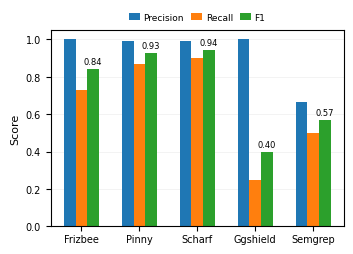


Metrics saved to: ../accuracy/results/count_no_line_selected_scanners_metrics.csv
Figure saved to: ../accuracy/results/scanner_accuracy.pdf


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Paths
# ============================================================

INPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_details.csv"

OUTPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_selected_scanners_metrics.csv"

FIGURE_FILE = ACCURACY_RESULTS_DIR / "scanner_accuracy.pdf"


# ============================================================
# Scanners we want to show
# ============================================================

SELECTED_SCANNERS = [
    "frizbee",
    "pinny",
    "scharf",
    "ggshield",
    "semgrep",
]


# ============================================================
# Load results
# ============================================================

df = pd.read_csv(INPUT_FILE)

required_columns = {
    "tool",
    "weakness_type",
    "status"
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing columns in {INPUT_FILE}: {missing}"
    )


# ============================================================
# Normalize
# ============================================================

df["tool"] = (
    df["tool"]
    .str.strip()
    .str.lower()
)

df["weakness_type"] = (
    df["weakness_type"]
    .str.strip()
    .str.upper()
)

df["status"] = (
    df["status"]
    .str.strip()
    .str.upper()
)


# ============================================================
# Keep only selected scanners
# ============================================================

df = df[
    df["tool"].isin(
        SELECTED_SCANNERS
    )
].copy()


# ============================================================
# Calculate TP / FP / FN + metrics PER SCANNER
#
# All in-scope weakness classes for each scanner are combined.
#
# Example:
# Semgrep:
#   PTW + IW
#   -> one overall Semgrep result
# ============================================================

rows = []


for tool in SELECTED_SCANNERS:

    subset = df[
        df["tool"] == tool
    ]

    counts = (
        subset["status"]
        .value_counts()
    )

    tp = int(
        counts.get("TP", 0)
    )

    fp = int(
        counts.get("FP", 0)
    )

    fn = int(
        counts.get("FN", 0)
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    f1 = (
        2 * precision * recall
        / (precision + recall)

        if (
            not np.isnan(precision)
            and
            not np.isnan(recall)
            and
            (precision + recall) > 0
        )

        else np.nan
    )


    # --------------------------------------------------------
    # Weakness classes represented
    # --------------------------------------------------------

    weaknesses = sorted(
        subset["weakness_type"]
        .dropna()
        .unique()
    )


    rows.append({
        "tool": tool,
        "weaknesses": ", ".join(weaknesses),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    })


metrics = pd.DataFrame(
    rows
)


# ============================================================
# Save numerical results
# ============================================================

metrics.to_csv(
    OUTPUT_FILE,
    index=False
)


print("Selected scanner-level accuracy results:\n")

display(
    metrics.round(3)
)


# ============================================================
# Prepare labels
# ============================================================

metrics["label"] = (
    metrics["tool"]
    .str.capitalize()
)


# ============================================================
# Compact one-column figure
# ============================================================

x = np.arange(
    len(metrics)
)

width = 0.20


# IEEE single-column width is roughly 3.4–3.5 inches
fig, ax = plt.subplots(
    figsize=(3.45, 2.45)
)


# ============================================================
# Bars
# ============================================================

ax.bar(
    x - width,
    metrics["precision"],
    width,
    label="Precision"
)

ax.bar(
    x,
    metrics["recall"],
    width,
    label="Recall"
)

ax.bar(
    x + width,
    metrics["f1"],
    width,
    label="F1"
)


# ============================================================
# X axis
# ============================================================

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metrics["label"],
    fontsize=7
)


# ============================================================
# Y axis
# ============================================================

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score",
    fontsize=8
)

ax.tick_params(
    axis="y",
    labelsize=7
)

ax.tick_params(
    axis="x",
    labelsize=7,
    pad=2
)


# ============================================================
# Legend
# ============================================================

ax.legend(
    fontsize=6.5,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    frameon=False,
    columnspacing=0.8,
    handlelength=1.2,
    handletextpad=0.4
)


# ============================================================
# Grid
# ============================================================

ax.grid(
    axis="y",
    alpha=0.20,
    linewidth=0.5
)

ax.set_axisbelow(
    True
)


# ============================================================
# Add F1 values above F1 bars
# ============================================================

for i, value in enumerate(
    metrics["f1"]
):

    if not np.isnan(value):

        ax.text(
            i + width,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


# ============================================================
# Tight layout
# ============================================================

plt.tight_layout(
    pad=0.4
)


# ============================================================
# Save figure
# ============================================================

fig.savefig(
    FIGURE_FILE,
    bbox_inches="tight"
)


# ============================================================
# Show
# ============================================================

plt.show()


print(
    f"\nMetrics saved to: {OUTPUT_FILE}"
)

print(
    f"Figure saved to: {FIGURE_FILE}"
)


Count-based accuracy per scanner:



,tool,weaknesses,TP,FP,FN,precision,recall,f1
0,poutine,"AIW, EPW, IW, KVCW, PTW, SEW",8,6,62,0.571,0.114,0.190
1,zizmor,"AIW, EPW, GRCW, HGW, IW, KVCW, PTW, SEW, UDW",86,139,361,0.382,0.192,0.256
2,actionlint,"CFW, EPW, GRCW, IW, SEW",18,23,52,0.439,0.257,0.324
3,scorecard,"EPW, HGW, IW, PTW, UDW",382,82,28,0.823,0.932,0.874


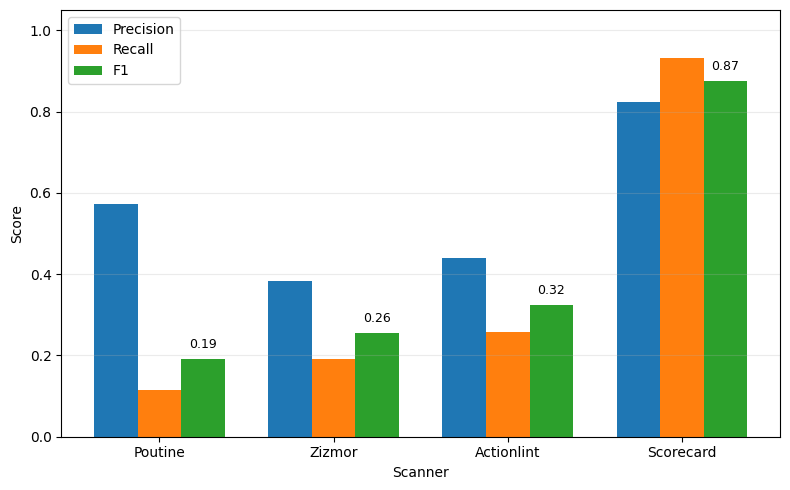

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Paths
# ============================================================

INPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_details.csv"

OUTPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_general_scanners_metrics.csv"


# ============================================================
# Scanners to compare
# ============================================================

SELECTED_SCANNERS = [
    "poutine",
    "zizmor",
    "actionlint",
    "scorecard",
]


# ============================================================
# Load results
# ============================================================

df = pd.read_csv(INPUT_FILE)


required_columns = {
    "tool",
    "weakness_type",
    "status"
}


missing = (
    required_columns
    -
    set(df.columns)
)


if missing:
    raise ValueError(
        f"Missing columns in {INPUT_FILE}: {missing}"
    )


# ============================================================
# Normalize
# ============================================================

df["tool"] = (
    df["tool"]
    .str.strip()
    .str.lower()
)


df["weakness_type"] = (
    df["weakness_type"]
    .str.strip()
    .str.upper()
)


df["status"] = (
    df["status"]
    .str.strip()
    .str.upper()
)


# ============================================================
# Keep only selected scanners
# ============================================================

df = df[
    df["tool"].isin(
        SELECTED_SCANNERS
    )
].copy()


# ============================================================
# Calculate metrics PER SCANNER
#
# All in-scope weakness classes are combined.
# ============================================================

rows = []


for tool in SELECTED_SCANNERS:

    subset = df[
        df["tool"] == tool
    ]


    counts = (
        subset["status"]
        .value_counts()
    )


    tp = int(
        counts.get(
            "TP",
            0
        )
    )


    fp = int(
        counts.get(
            "FP",
            0
        )
    )


    fn = int(
        counts.get(
            "FN",
            0
        )
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # F1
    # --------------------------------------------------------

    f1 = (
        2 * precision * recall
        /
        (precision + recall)

        if (
            not np.isnan(precision)
            and
            not np.isnan(recall)
            and
            (precision + recall) > 0
        )

        else np.nan
    )


    # --------------------------------------------------------
    # Weakness classes actually represented
    # --------------------------------------------------------

    weaknesses = sorted(
        subset[
            "weakness_type"
        ]
        .dropna()
        .unique()
    )


    rows.append({
        "tool":
            tool,

        "weaknesses":
            ", ".join(
                weaknesses
            ),

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,
    })


metrics = pd.DataFrame(
    rows
)


# ============================================================
# Save numerical results
# ============================================================

metrics.to_csv(
    OUTPUT_FILE,
    index=False
)


print(
    "Count-based accuracy per scanner:\n"
)


display(
    metrics.round(3)
)


# ============================================================
# Prepare labels
# ============================================================

metrics["label"] = (
    metrics["tool"]
    .str.capitalize()
)


# ============================================================
# Plot Precision / Recall / F1
# ============================================================

x = np.arange(
    len(metrics)
)


width = 0.25


fig, ax = plt.subplots(
    figsize=(8, 5)
)


# ------------------------------------------------------------
# Precision
# ------------------------------------------------------------

ax.bar(
    x - width,
    metrics["precision"],
    width,
    label="Precision"
)


# ------------------------------------------------------------
# Recall
# ------------------------------------------------------------

ax.bar(
    x,
    metrics["recall"],
    width,
    label="Recall"
)


# ------------------------------------------------------------
# F1
# ------------------------------------------------------------

ax.bar(
    x + width,
    metrics["f1"],
    width,
    label="F1"
)


# ============================================================
# Formatting
# ============================================================

ax.set_xticks(
    x
)


ax.set_xticklabels(
    metrics["label"]
)


ax.set_ylim(
    0,
    1.05
)


ax.set_ylabel(
    "Score"
)


ax.set_xlabel(
    "Scanner"
)


ax.legend()


ax.grid(
    axis="y",
    alpha=0.25
)


# ============================================================
# Add F1 value above F1 bars
# ============================================================

for i, value in enumerate(
    metrics["f1"]
):

    if not np.isnan(
        value
    ):

        ax.text(
            i + width,
            value + 0.02,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.tight_layout()

plt.show()


Scanners covering UDW: ['frizbee', 'pinny', 'scharf', 'scorecard', 'zizmor']

UDW scanner accuracy:



,tool,TP,FP,FN,precision,recall
0,frizbee,241,0,89,1.000,0.730
1,pinny,287,2,43,0.993,0.870
2,scharf,297,2,33,0.993,0.900
3,scorecard,322,39,8,0.892,0.976
4,zizmor,45,0,285,1.000,0.136


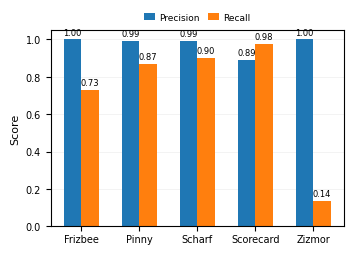


Metrics saved to: ../accuracy/results/udw_scanners_metrics.csv
Figure saved to: ../accuracy/results/udw_scanners_accuracy.pdf


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Paths
# ============================================================

INPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_details.csv"

OUTPUT_FILE = ACCURACY_RESULTS_DIR / "udw_scanners_metrics.csv"

FIGURE_FILE = ACCURACY_RESULTS_DIR / "udw_scanners_accuracy.pdf"


# ============================================================
# Load results
# ============================================================

df = pd.read_csv(INPUT_FILE)

required_columns = {
    "tool",
    "weakness_type",
    "status"
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing columns in {INPUT_FILE}: {missing}"
    )


# ============================================================
# Normalize
# ============================================================

df["tool"] = (
    df["tool"]
    .str.strip()
    .str.lower()
)

df["weakness_type"] = (
    df["weakness_type"]
    .str.strip()
    .str.upper()
)

df["status"] = (
    df["status"]
    .str.strip()
    .str.upper()
)


# ============================================================
# Keep only UDW
#
# Because count_no_line_details.csv is already scope-aware,
# this automatically keeps ONLY scanners that cover UDW.
# ============================================================

udw = df[
    df["weakness_type"] == "UDW"
].copy()


# ============================================================
# Get scanners that actually have UDW in their scope
# ============================================================

UDW_SCANNERS = (
    udw["tool"]
    .dropna()
    .unique()
    .tolist()
)

print(
    "Scanners covering UDW:",
    UDW_SCANNERS
)


# ============================================================
# Calculate TP / FP / FN / Precision / Recall
# ============================================================

rows = []


for tool in UDW_SCANNERS:

    subset = udw[
        udw["tool"] == tool
    ]

    counts = (
        subset["status"]
        .value_counts()
    )

    tp = int(
        counts.get("TP", 0)
    )

    fp = int(
        counts.get("FP", 0)
    )

    fn = int(
        counts.get("FN", 0)
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )


    rows.append({
        "tool": tool,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
    })


metrics = pd.DataFrame(rows)


# ============================================================
# Save results
# ============================================================

metrics.to_csv(
    OUTPUT_FILE,
    index=False
)


print("\nUDW scanner accuracy:\n")

display(
    metrics.round(3)
)


# ============================================================
# Labels
# ============================================================

metrics["label"] = (
    metrics["tool"]
    .str.capitalize()
)


# ============================================================
# Plot Precision and Recall
# ============================================================

x = np.arange(
    len(metrics)
)

width = 0.30


# Compact IEEE one-column figure
fig, ax = plt.subplots(
    figsize=(3.45, 2.45)
)


# Precision
ax.bar(
    x - width / 2,
    metrics["precision"],
    width,
    label="Precision"
)


# Recall
ax.bar(
    x + width / 2,
    metrics["recall"],
    width,
    label="Recall"
)


# ============================================================
# Formatting
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    metrics["label"],
    fontsize=7
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score",
    fontsize=8
)

ax.tick_params(
    axis="y",
    labelsize=7
)

ax.tick_params(
    axis="x",
    labelsize=7,
    pad=2
)


ax.legend(
    fontsize=6.5,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    frameon=False,
    columnspacing=1.0,
    handlelength=1.2,
    handletextpad=0.4
)


ax.grid(
    axis="y",
    alpha=0.20,
    linewidth=0.5
)

ax.set_axisbelow(True)


# ============================================================
# Add values above bars
# ============================================================

for i, value in enumerate(
    metrics["precision"]
):

    ax.text(
        i - width / 2,
        value + 0.015,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=6
    )


for i, value in enumerate(
    metrics["recall"]
):

    ax.text(
        i + width / 2,
        value + 0.015,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=6
    )


# ============================================================
# Save + show
# ============================================================

plt.tight_layout(
    pad=0.4
)

fig.savefig(
    FIGURE_FILE,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nMetrics saved to: {OUTPUT_FILE}"
)

print(
    f"Figure saved to: {FIGURE_FILE}"
)


Scanners covering HGW: ['scorecard', 'zizmor']

HGW scanner accuracy:



,tool,TP,FP,FN,precision,recall
0,scorecard,29,23,0,0.558,1.0
1,zizmor,0,0,29,NaN,0.0


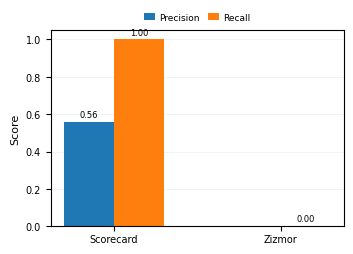


Metrics saved to: ../accuracy/results/hgw_scanners_metrics.csv
Figure saved to: ../accuracy/results/hgw_scanners_accuracy.pdf


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Paths
# ============================================================

INPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_details.csv"

OUTPUT_FILE = ACCURACY_RESULTS_DIR / "hgw_scanners_metrics.csv"

FIGURE_FILE = ACCURACY_RESULTS_DIR / "hgw_scanners_accuracy.pdf"


# ============================================================
# Load results
# ============================================================

df = pd.read_csv(INPUT_FILE)

required_columns = {
    "tool",
    "weakness_type",
    "status"
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing columns in {INPUT_FILE}: {missing}"
    )


# ============================================================
# Normalize
# ============================================================

df["tool"] = (
    df["tool"]
    .str.strip()
    .str.lower()
)

df["weakness_type"] = (
    df["weakness_type"]
    .str.strip()
    .str.upper()
)

df["status"] = (
    df["status"]
    .str.strip()
    .str.upper()
)


# ============================================================
# Keep only HGW
#
# count_no_line_details.csv is already scope-aware,
# so this automatically keeps only scanners that cover HGW.
# ============================================================

hgw = df[
    df["weakness_type"] == "HGW"
].copy()


# ============================================================
# Get scanners that actually have HGW in their scope
# ============================================================

HGW_SCANNERS = (
    hgw["tool"]
    .dropna()
    .unique()
    .tolist()
)

print(
    "Scanners covering HGW:",
    HGW_SCANNERS
)


# ============================================================
# Calculate TP / FP / FN / Precision / Recall
# ============================================================

rows = []


for tool in HGW_SCANNERS:

    subset = hgw[
        hgw["tool"] == tool
    ]

    counts = (
        subset["status"]
        .value_counts()
    )

    tp = int(
        counts.get("TP", 0)
    )

    fp = int(
        counts.get("FP", 0)
    )

    fn = int(
        counts.get("FN", 0)
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )


    rows.append({
        "tool": tool,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
    })


metrics = pd.DataFrame(rows)


# ============================================================
# Save results
# ============================================================

metrics.to_csv(
    OUTPUT_FILE,
    index=False
)


print("\nHGW scanner accuracy:\n")

display(
    metrics.round(3)
)


# ============================================================
# Labels
# ============================================================

metrics["label"] = (
    metrics["tool"]
    .str.capitalize()
)


# ============================================================
# Plot Precision and Recall
# ============================================================

x = np.arange(
    len(metrics)
)

width = 0.30


# Compact IEEE one-column figure
fig, ax = plt.subplots(
    figsize=(3.45, 2.45)
)


# Precision
ax.bar(
    x - width / 2,
    metrics["precision"],
    width,
    label="Precision"
)


# Recall
ax.bar(
    x + width / 2,
    metrics["recall"],
    width,
    label="Recall"
)


# ============================================================
# Formatting
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    metrics["label"],
    fontsize=7
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score",
    fontsize=8
)

ax.tick_params(
    axis="y",
    labelsize=7
)

ax.tick_params(
    axis="x",
    labelsize=7,
    pad=2
)


ax.legend(
    fontsize=6.5,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    frameon=False,
    columnspacing=1.0,
    handlelength=1.2,
    handletextpad=0.4
)


ax.grid(
    axis="y",
    alpha=0.20,
    linewidth=0.5
)

ax.set_axisbelow(True)


# ============================================================
# Add values above bars
# ============================================================

for i, value in enumerate(
    metrics["precision"]
):

    if not np.isnan(value):

        ax.text(
            i - width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


for i, value in enumerate(
    metrics["recall"]
):

    if not np.isnan(value):

        ax.text(
            i + width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


# ============================================================
# Save + show
# ============================================================

plt.tight_layout(
    pad=0.4
)

fig.savefig(
    FIGURE_FILE,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nMetrics saved to: {OUTPUT_FILE}"
)

print(
    f"Figure saved to: {FIGURE_FILE}"
)


Scanners covering GRCW: ['actionlint', 'zizmor']

GRCW scanner accuracy:



,tool,TP,FP,FN,precision,recall
0,actionlint,18,19,0,0.486,1.0
1,zizmor,0,0,18,NaN,0.0


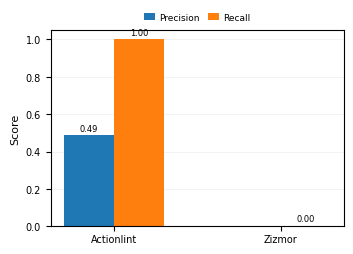


Metrics saved to: ../accuracy/results/grcw_scanners_metrics.csv
Figure saved to: ../accuracy/results/grcw_scanners_accuracy.pdf


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Paths
# ============================================================

INPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_details.csv"

OUTPUT_FILE = ACCURACY_RESULTS_DIR / "grcw_scanners_metrics.csv"

FIGURE_FILE = ACCURACY_RESULTS_DIR / "grcw_scanners_accuracy.pdf"


# ============================================================
# Load results
# ============================================================

df = pd.read_csv(INPUT_FILE)

required_columns = {
    "tool",
    "weakness_type",
    "status"
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing columns in {INPUT_FILE}: {missing}"
    )


# ============================================================
# Normalize
# ============================================================

df["tool"] = (
    df["tool"]
    .str.strip()
    .str.lower()
)

df["weakness_type"] = (
    df["weakness_type"]
    .str.strip()
    .str.upper()
)

df["status"] = (
    df["status"]
    .str.strip()
    .str.upper()
)


# ============================================================
# Keep only GRCW
#
# count_no_line_details.csv is already scope-aware,
# so this automatically keeps only scanners that cover GRCW.
# ============================================================

grcw = df[
    df["weakness_type"] == "GRCW"
].copy()


# ============================================================
# Get scanners that actually have GRCW in their scope
# ============================================================

GRCW_SCANNERS = (
    grcw["tool"]
    .dropna()
    .unique()
    .tolist()
)

print(
    "Scanners covering GRCW:",
    GRCW_SCANNERS
)


# ============================================================
# Calculate TP / FP / FN / Precision / Recall
# ============================================================

rows = []


for tool in GRCW_SCANNERS:

    subset = grcw[
        grcw["tool"] == tool
    ]

    counts = (
        subset["status"]
        .value_counts()
    )

    tp = int(
        counts.get("TP", 0)
    )

    fp = int(
        counts.get("FP", 0)
    )

    fn = int(
        counts.get("FN", 0)
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )


    rows.append({
        "tool": tool,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
    })


metrics = pd.DataFrame(rows)


# ============================================================
# Save results
# ============================================================

metrics.to_csv(
    OUTPUT_FILE,
    index=False
)


print("\nGRCW scanner accuracy:\n")

display(
    metrics.round(3)
)


# ============================================================
# Labels
# ============================================================

metrics["label"] = (
    metrics["tool"]
    .str.capitalize()
)


# ============================================================
# Plot Precision and Recall
# ============================================================

x = np.arange(
    len(metrics)
)

width = 0.30


# Compact IEEE one-column figure
fig, ax = plt.subplots(
    figsize=(3.45, 2.45)
)


# Precision
ax.bar(
    x - width / 2,
    metrics["precision"],
    width,
    label="Precision"
)


# Recall
ax.bar(
    x + width / 2,
    metrics["recall"],
    width,
    label="Recall"
)


# ============================================================
# Formatting
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    metrics["label"],
    fontsize=7
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score",
    fontsize=8
)

ax.tick_params(
    axis="y",
    labelsize=7
)

ax.tick_params(
    axis="x",
    labelsize=7,
    pad=2
)


ax.legend(
    fontsize=6.5,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    frameon=False,
    columnspacing=1.0,
    handlelength=1.2,
    handletextpad=0.4
)


ax.grid(
    axis="y",
    alpha=0.20,
    linewidth=0.5
)

ax.set_axisbelow(True)


# ============================================================
# Add values above bars
# ============================================================

for i, value in enumerate(
    metrics["precision"]
):

    if not np.isnan(value):

        ax.text(
            i - width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


for i, value in enumerate(
    metrics["recall"]
):

    if not np.isnan(value):

        ax.text(
            i + width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


# ============================================================
# Save + show
# ============================================================

plt.tight_layout(
    pad=0.4
)

fig.savefig(
    FIGURE_FILE,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nMetrics saved to: {OUTPUT_FILE}"
)

print(
    f"Figure saved to: {FIGURE_FILE}"
)


Poutine weakness scope:
['AIW', 'CFW', 'EPW', 'IW', 'KVCW', 'PTW', 'SEW']

Breakdown before aggregation:



status                 FN  FP  TP
tool    weakness_type            
poutine AIW             4   3   3
        EPW            35   0   0
        IW             11   0   2
        KVCW            5   0   3
        PTW             3   3   0
        SEW             4   0   0
zizmor  AIW             2  84   5
        EPW            14  40  21
        IW              0  13  13
        KVCW            8   0   0
        PTW             1   2   2
        SEW             4   0   0


Poutine vs Zizmor on Poutine's weakness scope:



,tool,weaknesses,TP,FP,FN,precision,recall
0,poutine,"AIW, CFW, EPW, IW, KVCW, PTW, SEW",8,6,62,0.571,0.114
1,zizmor,"AIW, CFW, EPW, IW, KVCW, PTW, SEW",41,139,29,0.228,0.586


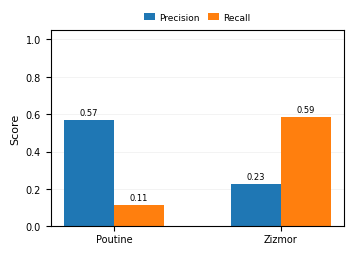


Metrics saved to: ../accuracy/results/poutine_vs_zizmor_poutine_scope_metrics.csv
Figure saved to: ../accuracy/results/poutine_vs_zizmor_poutine_scope.pdf


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Paths
# ============================================================

INPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_details.csv"


OUTPUT_FILE = ACCURACY_RESULTS_DIR / "poutine_vs_zizmor_poutine_scope_metrics.csv"

FIGURE_FILE = ACCURACY_RESULTS_DIR / "poutine_vs_zizmor_poutine_scope.pdf"


# ============================================================
# Scanners to compare
# ============================================================

SELECTED_SCANNERS = [
    "poutine",
    "zizmor",
]


# ============================================================
# Weakness normalization
# ============================================================

WEAKNESS_MAP = {
    "artifact-integrity-weakness": "AIW",
    "control-flow-weakness": "CFW",
    "excessive-permission-weakness": "EPW",
    "github-runner-compatibility-weakness": "GRCW",
    "hardening-gap-weakness": "HGW",
    "injection-weakness": "IW",
    "known-vulnerable-component-weakness": "KVCW",
    "privileged-trigger-weakness": "PTW",
    "secrets-exposure-weakness": "SEW",
    "unpinned-dependency-weakness": "UDW",
}


def normalize_weakness(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    # Already an acronym
    upper = value.upper()

    if upper in WEAKNESS_MAP.values():
        return upper

    # Normalized full weakness name
    lower = value.lower()

    if lower in WEAKNESS_MAP:
        return WEAKNESS_MAP[lower]

    # Handle names such as:
    # "Injection Weakness (IW)"
    for acronym in WEAKNESS_MAP.values():

        if f"({acronym})" in upper:
            return acronym

    return None


# ============================================================
# Determine Poutine's CURRENT scope from rules_map.csv
# ============================================================

rules = pd.read_csv(RULES_FILE)

required_rule_columns = {
    "tool_name",
    "weakness"
}

missing = required_rule_columns - set(rules.columns)

if missing:
    raise ValueError(
        f"Missing columns in {RULES_FILE}: {missing}"
    )


rules["tool_name"] = (
    rules["tool_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

rules["weakness_normalized"] = (
    rules["weakness"]
    .apply(normalize_weakness)
)


POUTINE_WEAKNESSES = sorted(
    rules.loc[
        rules["tool_name"] == "poutine",
        "weakness_normalized"
    ]
    .dropna()
    .unique()
    .tolist()
)


print(
    "Poutine weakness scope:"
)

print(
    POUTINE_WEAKNESSES
)


# ============================================================
# Load count-based results
# ============================================================

df = pd.read_csv(INPUT_FILE)

required_columns = {
    "tool",
    "weakness_type",
    "status"
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing columns in {INPUT_FILE}: {missing}"
    )


# ============================================================
# Normalize
# ============================================================

df["tool"] = (
    df["tool"]
    .str.strip()
    .str.lower()
)

df["weakness_type"] = (
    df["weakness_type"]
    .str.strip()
    .str.upper()
)

df["status"] = (
    df["status"]
    .str.strip()
    .str.upper()
)


# ============================================================
# Keep only:
#
# 1. Poutine and Zizmor
# 2. Weaknesses covered by Poutine
#
# This gives both scanners exactly the same evaluation scope.
# ============================================================

comparison = df[
    df["tool"].isin(
        SELECTED_SCANNERS
    )
    &
    df["weakness_type"].isin(
        POUTINE_WEAKNESSES
    )
].copy()


# ============================================================
# Optional: show findings per weakness before aggregation
#
# This is useful only for verification.
# The final figure is NOT per weakness.
# ============================================================

verification = (
    comparison
    .groupby(
        [
            "tool",
            "weakness_type",
            "status"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)


print(
    "\nBreakdown before aggregation:\n"
)

display(
    verification
)


# ============================================================
# Aggregate ALL Poutine weakness classes PER SCANNER
#
# Example:
#
# Poutine:
# AIW TP + CFW TP + EPW TP + IW TP + ...
#
# Zizmor:
# AIW TP + CFW TP + EPW TP + IW TP + ...
#
# Then calculate ONE precision and recall per scanner.
# ============================================================

rows = []


for tool in SELECTED_SCANNERS:

    subset = comparison[
        comparison["tool"] == tool
    ]

    counts = (
        subset["status"]
        .value_counts()
    )


    tp = int(
        counts.get("TP", 0)
    )

    fp = int(
        counts.get("FP", 0)
    )

    fn = int(
        counts.get("FN", 0)
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )


    rows.append({
        "tool": tool,
        "weaknesses": ", ".join(
            POUTINE_WEAKNESSES
        ),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
    })


metrics = pd.DataFrame(
    rows
)


# ============================================================
# Save numerical results
# ============================================================

metrics.to_csv(
    OUTPUT_FILE,
    index=False
)


print(
    "\nPoutine vs Zizmor on Poutine's weakness scope:\n"
)

display(
    metrics.round(3)
)


# ============================================================
# Labels
# ============================================================

metrics["label"] = (
    metrics["tool"]
    .str.capitalize()
)


# ============================================================
# Plot Precision and Recall
#
# ONE group per scanner, NOT per weakness
# ============================================================

x = np.arange(
    len(metrics)
)

width = 0.30


fig, ax = plt.subplots(
    figsize=(3.45, 2.45)
)


# Precision
ax.bar(
    x - width / 2,
    metrics["precision"],
    width,
    label="Precision"
)


# Recall
ax.bar(
    x + width / 2,
    metrics["recall"],
    width,
    label="Recall"
)


# ============================================================
# Formatting
# ============================================================

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metrics["label"],
    fontsize=7
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score",
    fontsize=8
)

ax.tick_params(
    axis="y",
    labelsize=7
)

ax.tick_params(
    axis="x",
    labelsize=7,
    pad=2
)


ax.legend(
    fontsize=6.5,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    frameon=False,
    columnspacing=1.0,
    handlelength=1.2,
    handletextpad=0.4
)


ax.grid(
    axis="y",
    alpha=0.20,
    linewidth=0.5
)

ax.set_axisbelow(
    True
)


# ============================================================
# Add Precision values
# ============================================================

for i, value in enumerate(
    metrics["precision"]
):

    if not np.isnan(value):

        ax.text(
            i - width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


# ============================================================
# Add Recall values
# ============================================================

for i, value in enumerate(
    metrics["recall"]
):

    if not np.isnan(value):

        ax.text(
            i + width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


# ============================================================
# Save + show
# ============================================================

plt.tight_layout(
    pad=0.4
)

fig.savefig(
    FIGURE_FILE,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nMetrics saved to: {OUTPUT_FILE}"
)

print(
    f"Figure saved to: {FIGURE_FILE}"
)


Common weakness scope:
['EPW', 'IW', 'PTW']

Scanner scopes:
zizmor: ['AIW', 'CFW', 'EPW', 'GRCW', 'HGW', 'IW', 'KVCW', 'PTW', 'SEW', 'UDW']
poutine: ['AIW', 'CFW', 'EPW', 'IW', 'KVCW', 'PTW', 'SEW']
scorecard: ['EPW', 'HGW', 'IW', 'PTW', 'UDW']

Breakdown per weakness before aggregation:



status                   FN  FP  TP
tool      weakness_type            
poutine   EPW            35   0   0
          IW             11   0   2
          PTW             3   3   0
scorecard EPW             5  20  30
          IW             13   0   0
          PTW             2   0   1
zizmor    EPW            14  40  21
          IW              0  13  13
          PTW             1   2   2


Zizmor vs Poutine vs Scorecard on their common weakness scope:



,tool,weaknesses,TP,FP,FN,precision,recall
0,zizmor,"EPW, IW, PTW",36,55,15,0.396,0.706
1,poutine,"EPW, IW, PTW",2,3,49,0.400,0.039
2,scorecard,"EPW, IW, PTW",31,20,20,0.608,0.608


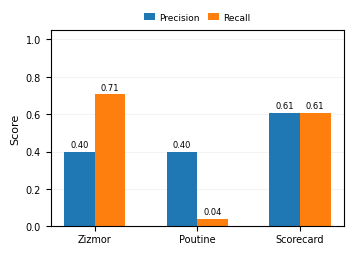


Metrics saved to: ../accuracy/results/zizmor_poutine_scorecard_common_scope_metrics.csv
Figure saved to: ../accuracy/results/zizmor_poutine_scorecard_common_scope.pdf


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# Paths
# ============================================================

INPUT_FILE = ACCURACY_RESULTS_DIR / "count_no_line_details.csv"


OUTPUT_FILE = ACCURACY_RESULTS_DIR / "zizmor_poutine_scorecard_common_scope_metrics.csv"

FIGURE_FILE = ACCURACY_RESULTS_DIR / "zizmor_poutine_scorecard_common_scope.pdf"


# ============================================================
# Scanners to compare
# ============================================================

SELECTED_SCANNERS = [
    "zizmor",
    "poutine",
    "scorecard",
]


# ============================================================
# Weakness normalization
# ============================================================

WEAKNESS_MAP = {
    "artifact-integrity-weakness": "AIW",
    "control-flow-weakness": "CFW",
    "excessive-permission-weakness": "EPW",
    "github-runner-compatibility-weakness": "GRCW",
    "hardening-gap-weakness": "HGW",
    "injection-weakness": "IW",
    "known-vulnerable-component-weakness": "KVCW",
    "privileged-trigger-weakness": "PTW",
    "secrets-exposure-weakness": "SEW",
    "unpinned-dependency-weakness": "UDW",
}


def normalize_weakness(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    # Already acronym
    upper = value.upper()

    if upper in WEAKNESS_MAP.values():
        return upper

    # Normalized weakness name
    lower = value.lower()

    if lower in WEAKNESS_MAP:
        return WEAKNESS_MAP[lower]

    # Handle:
    # "Injection Weakness (IW)"
    for acronym in WEAKNESS_MAP.values():

        if f"({acronym})" in upper:
            return acronym

    return None


# ============================================================
# Load rules_map.csv
# ============================================================

rules = pd.read_csv(
    RULES_FILE
)

required_rule_columns = {
    "tool_name",
    "weakness"
}

missing = (
    required_rule_columns
    -
    set(rules.columns)
)

if missing:
    raise ValueError(
        f"Missing columns in {RULES_FILE}: {missing}"
    )


# Normalize tool names
rules["tool_name"] = (
    rules["tool_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# Normalize weakness
rules["weakness_normalized"] = (
    rules["weakness"]
    .apply(normalize_weakness)
)


# ============================================================
# Build scope for each scanner
# ============================================================

scanner_scope = {}


for tool in SELECTED_SCANNERS:

    scanner_scope[tool] = set(
        rules.loc[
            rules["tool_name"] == tool,
            "weakness_normalized"
        ]
        .dropna()
        .unique()
    )


# ============================================================
# Find weaknesses shared by ALL THREE scanners
# ============================================================

COMMON_WEAKNESSES = sorted(
    set.intersection(
        *[
            scanner_scope[tool]
            for tool in SELECTED_SCANNERS
        ]
    )
)


print(
    "Common weakness scope:"
)

print(
    COMMON_WEAKNESSES
)


# ============================================================
# Show individual scopes for verification
# ============================================================

print(
    "\nScanner scopes:"
)

for tool in SELECTED_SCANNERS:

    print(
        f"{tool}:",
        sorted(
            scanner_scope[tool]
        )
    )


# ============================================================
# Load count-based evaluation
# ============================================================

df = pd.read_csv(
    INPUT_FILE
)


required_columns = {
    "tool",
    "weakness_type",
    "status"
}

missing = (
    required_columns
    -
    set(df.columns)
)

if missing:
    raise ValueError(
        f"Missing columns in {INPUT_FILE}: {missing}"
    )


# ============================================================
# Normalize
# ============================================================

df["tool"] = (
    df["tool"]
    .str.strip()
    .str.lower()
)

df["weakness_type"] = (
    df["weakness_type"]
    .str.strip()
    .str.upper()
)

df["status"] = (
    df["status"]
    .str.strip()
    .str.upper()
)


# ============================================================
# Keep only:
#
# 1. Zizmor, Poutine, Scorecard
# 2. Weaknesses covered by ALL THREE
# ============================================================

comparison = df[
    df["tool"].isin(
        SELECTED_SCANNERS
    )
    &
    df["weakness_type"].isin(
        COMMON_WEAKNESSES
    )
].copy()


# ============================================================
# Verification table:
# TP / FP / FN per weakness before aggregation
# ============================================================

verification = (
    comparison
    .groupby(
        [
            "tool",
            "weakness_type",
            "status"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)


print(
    "\nBreakdown per weakness before aggregation:\n"
)

display(
    verification
)


# ============================================================
# Aggregate ALL COMMON weaknesses PER SCANNER
#
# Example:
#
# Zizmor:
# EPW + IW + PTW
#
# Poutine:
# EPW + IW + PTW
#
# Scorecard:
# EPW + IW + PTW
#
# Then calculate ONE Precision and Recall per scanner.
# ============================================================

rows = []


for tool in SELECTED_SCANNERS:

    subset = comparison[
        comparison["tool"] == tool
    ]


    counts = (
        subset["status"]
        .value_counts()
    )


    tp = int(
        counts.get(
            "TP",
            0
        )
    )

    fp = int(
        counts.get(
            "FP",
            0
        )
    )

    fn = int(
        counts.get(
            "FN",
            0
        )
    )


    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )


    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )


    rows.append({
        "tool": tool,
        "weaknesses": ", ".join(
            COMMON_WEAKNESSES
        ),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
    })


metrics = pd.DataFrame(
    rows
)


# ============================================================
# Save numerical results
# ============================================================

metrics.to_csv(
    OUTPUT_FILE,
    index=False
)


print(
    "\nZizmor vs Poutine vs Scorecard "
    "on their common weakness scope:\n"
)

display(
    metrics.round(3)
)


# ============================================================
# Labels
# ============================================================

metrics["label"] = (
    metrics["tool"]
    .str.capitalize()
)


# ============================================================
# Plot Precision and Recall
#
# ONE group per scanner
# ============================================================

x = np.arange(
    len(metrics)
)

width = 0.30


# Compact IEEE one-column figure
fig, ax = plt.subplots(
    figsize=(3.45, 2.45)
)


# Precision
ax.bar(
    x - width / 2,
    metrics["precision"],
    width,
    label="Precision"
)


# Recall
ax.bar(
    x + width / 2,
    metrics["recall"],
    width,
    label="Recall"
)


# ============================================================
# Formatting
# ============================================================

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metrics["label"],
    fontsize=7
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score",
    fontsize=8
)

ax.tick_params(
    axis="y",
    labelsize=7
)

ax.tick_params(
    axis="x",
    labelsize=7,
    pad=2
)


ax.legend(
    fontsize=6.5,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.13),
    frameon=False,
    columnspacing=1.0,
    handlelength=1.2,
    handletextpad=0.4
)


ax.grid(
    axis="y",
    alpha=0.20,
    linewidth=0.5
)

ax.set_axisbelow(
    True
)


# ============================================================
# Add Precision values
# ============================================================

for i, value in enumerate(
    metrics["precision"]
):

    if not np.isnan(value):

        ax.text(
            i - width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


# ============================================================
# Add Recall values
# ============================================================

for i, value in enumerate(
    metrics["recall"]
):

    if not np.isnan(value):

        ax.text(
            i + width / 2,
            value + 0.015,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=6
        )


# ============================================================
# Save + show
# ============================================================

plt.tight_layout(
    pad=0.4
)

fig.savefig(
    FIGURE_FILE,
    bbox_inches="tight"
)

plt.show()


print(
    f"\nMetrics saved to: {OUTPUT_FILE}"
)

print(
    f"Figure saved to: {FIGURE_FILE}"
)
